In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [58]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

Text(0, 0.5, 'Index')

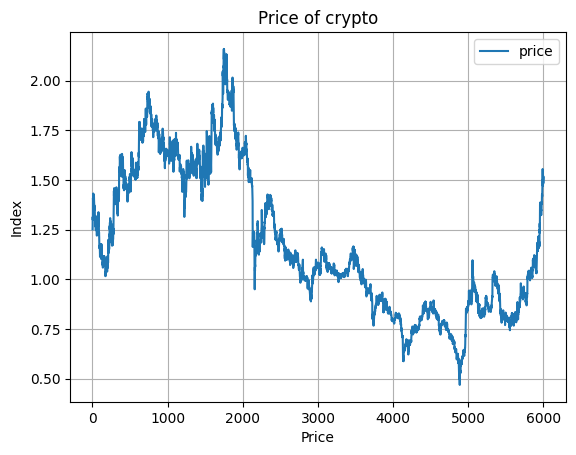

In [59]:
train.plot(x = 'id', y = 'price', grid = True)
plt.title("Price of crypto")
plt.xlabel("Price")
plt.ylabel("Index")

In [60]:
def feature_engineering(data):

    df = data.copy()

    lag_list = [1,2,3,7,14,30]
    rolling_list = [3,7,14,30]

    # lag
    for i in lag_list:
        df[f'lag_{i}'] = df['price'].shift(i)

    # rolling mean
    for i in rolling_list:
        df[f'rolling_mean_{i}'] = df['price'].rolling(i).mean()

    # rolling std
    for i in rolling_list:
        df[f'rolling_std_{i}'] = df['price'].rolling(i).std()

    # diff
    df['diff1'] = df['price'].diff(1)
    df['diff7'] = df['price'].diff(7)

    # expanding mean
    df['expanding_mean'] = df['price'].expanding().mean()

    # exponential moving average
    df['ewm_7'] = df['price'].ewm(span=7).mean()

    # trend
    df['trend'] = range(len(df))

    df = df.dropna()

    return df

In [61]:
train_fe = feature_engineering(train)

X_train = train_fe.drop(columns=['price', 'id'])
y_train = train_fe['price']

In [62]:
params = {
    "num_leaves":[15,31,63],
    "learning_rate":[0.01,0.03,0.05],
    "n_estimators":[400,600,800]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    LGBMRegressor(),
    params,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4794
[LightGBM] [Info] Number of data points in the train set: 5970, number of used features: 19
[LightGBM] [Info] Start training from score 1.176310
{'learning_rate': 0.05, 'n_estimators': 400, 'num_leaves': 15}


In [63]:
# model = XGBRegressor(
#     **grid.best_params_,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     min_child_weight=3,
#     gamma=0.1,
#     random_state=42
# )

# model.fit(X_train, y_train)

In [65]:
model = LGBMRegressor(
    **grid.best_params_,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4794
[LightGBM] [Info] Number of data points in the train set: 5970, number of used features: 19
[LightGBM] [Info] Start training from score 1.176310


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=400,
              num_leaves=15, random_state=42, subsample=0.8)

In [66]:
history = train['price'].tolist()

predictions = []

for i in range(len(test)):
  df = pd.DataFrame({'price' : history})

  df_fe = feature_engineering(df)
  X_last = df_fe.drop(columns='price').iloc[-1:]
  y = model.predict(X_last)[0]

  history.append(y)
  predictions.append(y)

In [67]:
test['price'] = predictions

print(test)

test.to_csv("submission.csv", index=False)

         id     price
0      6001  1.482334
1      6002  1.491597
2      6003  1.489693
3      6004  1.481286
4      6005  1.478142
...     ...       ...
3995   9996  1.479594
3996   9997  1.481045
3997   9998  1.483594
3998   9999  1.485843
3999  10000  1.484832

[4000 rows x 2 columns]
